# User analysis for all (non-categorized users) 

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import powerlaw, truncnorm
import powerlaw
from scipy import stats

In [3]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.


In [4]:
df.head()

,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",NaN,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",NaN,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,NaN,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [5]:
def normalize_data(df):
    df["id"]= pd.to_numeric(df["id"], errors='coerce').astype('Int64')   # Convert 'id' to numeric, coercing errors to NaN.
    df["sender_id"]= pd.to_numeric(df["sender_id"], errors='coerce').astype('Int64')   # Convert 'sender_id' to numeric, coercing errors to NaN.
    df["date"]= pd.to_datetime(df["date"], errors='coerce')   # Convert 'date' to datetime, coercing errors to NaT.
    df["edit_date"]= pd.to_datetime(df["edit_date"], errors='coerce')   # Convert 'edit_date' to datetime, coercing errors to NaT.
    df["reply_to_msg_id"]= pd.to_numeric(df["reply_to_msg_id"], errors='coerce').astype('Int64')   # Convert 'reply_to_message_id' to numeric, coercing errors to NaN.
    df["views"]= pd.to_numeric(df["views"], errors='coerce').astype('Int64')   # Convert 'views' to numeric, coercing errors to NaN.
    df["forwards"]= pd.to_numeric(df["forwards"], errors='coerce').astype('Int64')   # Convert 'forwards' to numeric, coercing errors to NaN.
    return df
df = normalize_data(df) # Normalize the data types of the DataFrame columns.


In [6]:
# Gather users with 100 or more messages sent 
active_users = df['sender_id'].value_counts()[df['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of users with 50 or more messages sent.
len(active_users)

26

In [7]:
active_users_messages = df[df['sender_id'].isin(active_users)] # Filter the DataFrame to include only messages from active users.


In [8]:
def filter_users_by_activity(active_users, messages_df, min_days=5):
    kept_users = []
    min_period = pd.Timedelta(days=min_days)
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        if user_dates.empty:
            continue
        period_of_activity = user_dates.max() - user_dates.min() # Calculate the period of activity of the user.
        if period_of_activity >= min_period:
            kept_users.append(user)
    return kept_users

active_users = filter_users_by_activity(active_users, df, min_days=5) # Filter active users by a minimum period of activity of 5 days.
len(active_users)

25

## Waiting times

In [9]:
# Plain power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail


def fit_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        if show_results:
            print("=" * 70)
            print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
            print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        _, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    if show_results:
        print("=" * 70)
        print(f"POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_pl:.4f}")
        print(f"xmin: {xmin_pl:.4f}")
        print(f"sigma: {sigma_pl:.4f}")
        n_tail_pl = int(np.sum(data_pl >= xmin_pl))
        print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
            ("power_law", "lognormal", "Power Law vs Lognormal"),
            ("power_law", "exponential", "Power Law vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print("  Power law is significantly better")
                else:
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:
                print("  No significant difference")

        print("\n" + "=" * 70)
        print(f"KS distance (power law): {ks_pl:.4f}")
        print(f"KS p-value (tail): {ks_p_pl:.6g}")
        print("=" * 70)

    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
        fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
        fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return fit_pl

In [10]:
# Truncated power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail
def fit_truncated_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    tpl = fit_pl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "lambda_", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)
    if show_results:
        print("=" * 70)
        print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_tpl:.4f}")
        print(f"lambda: {lambda_tpl:.4f}")
        print(f"xmin: {xmin_tpl:.4f}")
        print(f"sigma: {sigma_tpl:.4f}")
        n_tail_tpl = int(np.sum(data_pl >= xmin_tpl))
        print(f"Data points above xmin: {n_tail_tpl} / {len(data_pl)} ({100 * n_tail_tpl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("TRUNCATED POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
            ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
            ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print(f"  Truncated power law is significantly better")
                else:                
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:            
                print("  No significant difference")
        tail_tpl = np.sort(data_pl[data_pl >= xmin_tpl])
        if len(tail_tpl) == 0:
            ks_tpl = float("nan")
            ks_p_tpl = float("nan")
        else:
            empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
            try:
                model_cdf_tpl = tpl.cdf(tail_tpl)
            except Exception:
                model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
            ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
            ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
        
        print("\n" + "=" * 70)
        print(f"KS distance (truncated power law): {ks_tpl:.4f}")
        print(f"KS p-value (tail): {ks_p_tpl:.6g}")
        print("=" * 70)
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        tpl.plot_pdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[0])
        fit_pl.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Truncated Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        tpl.plot_ccdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[1])
        fit_pl.power_law.plot_ccdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Truncated Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    return fit_pl


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

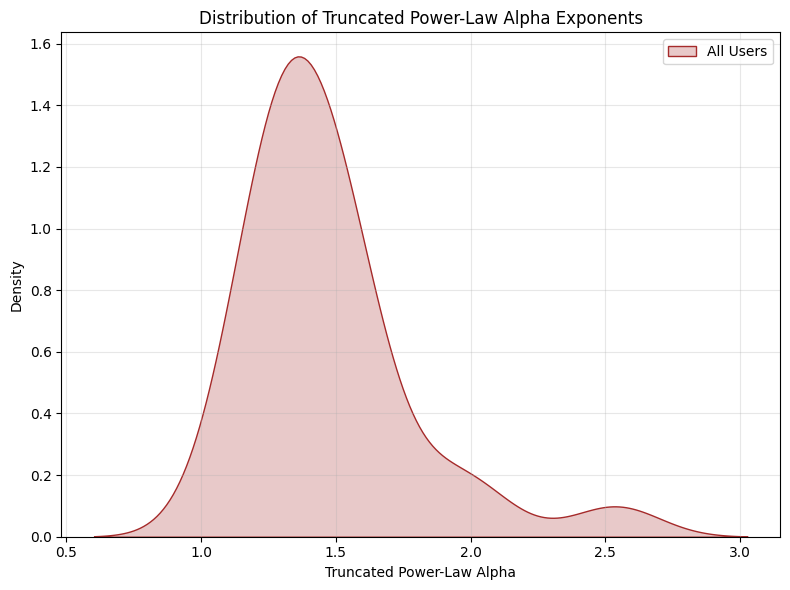

In [11]:
# Compare the truncated power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_truncated_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.truncated_power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
alphas, lambdas = extract_truncated_power_law_params(active_users, active_users_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(alphas, color='brown', label='All Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

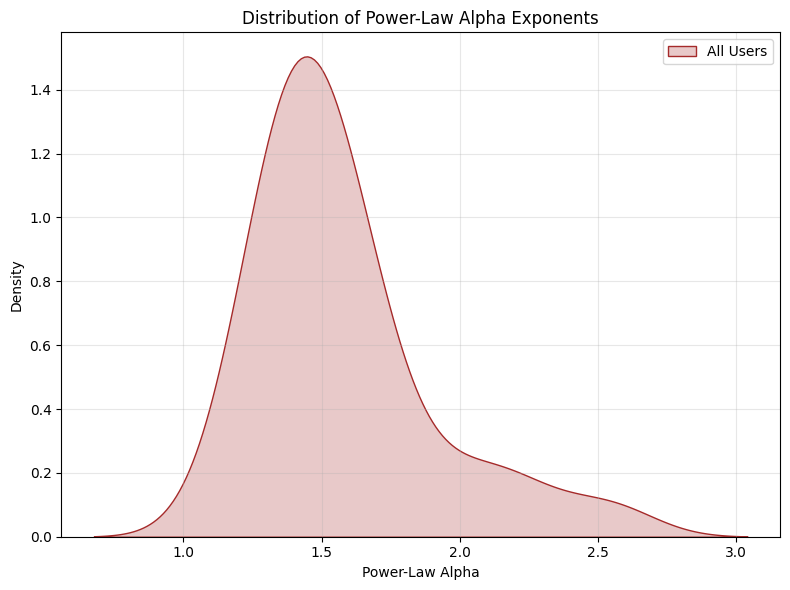

In [12]:
# Compare the normal power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
alphas, lambdas = extract_power_law_params(active_users, active_users_messages)
plt.figure(figsize=(8,6))
sns.kdeplot(alphas, color='brown', label='All Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Waiting times for users with over 50 messages and 5 days of activity.

In [13]:
# Gather users with 50 or more messages sent 
active_users_50 = df['sender_id'].value_counts()[df['sender_id'].value_counts() >= 50].index.tolist() # Gather sender IDs of users with 50 or more messages sent.
len(active_users_50)

50

In [14]:
active_users_messages_50 = df[df['sender_id'].isin(active_users_50)] # Filter the DataFrame to include only messages from active users.

In [15]:
active_users_50 = filter_users_by_activity(active_users_50, df, min_days=5) # Filter active users by a minimum period of activity of 5 days.
len(active_users_50)

37

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

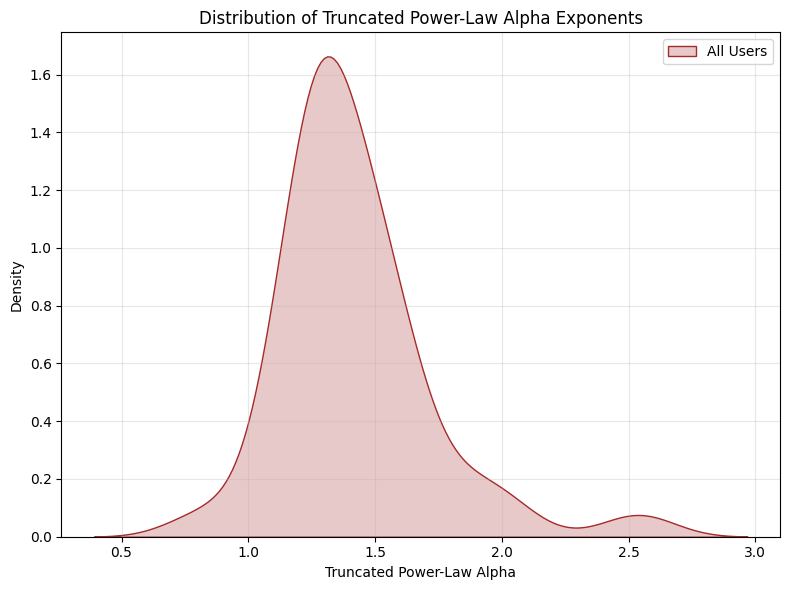

In [16]:
alphas_50, lambdas_50 = extract_truncated_power_law_params(active_users_50, active_users_messages_50)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(alphas_50, color='brown', label='All Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

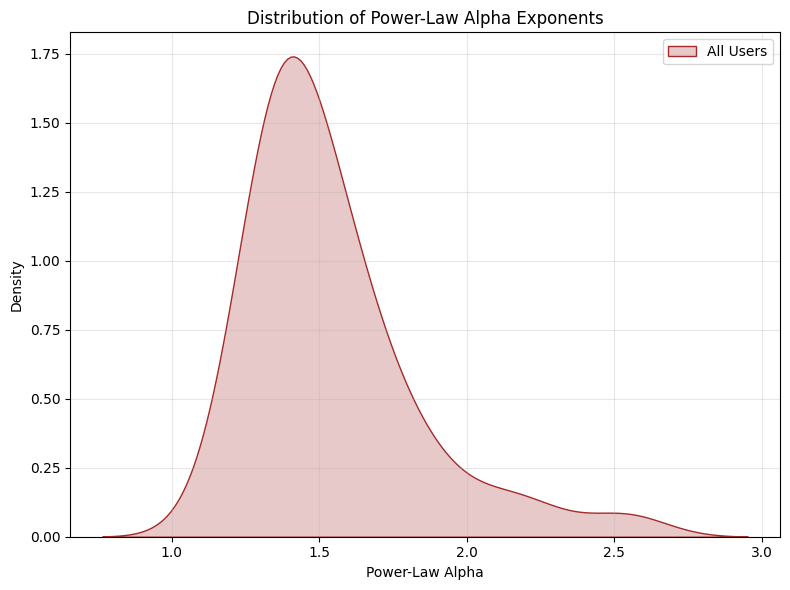

In [17]:
alphas_50, lambdas_50 = extract_power_law_params(active_users_50, active_users_messages_50)
plt.figure(figsize=(8,6))
sns.kdeplot(alphas_50, color='brown', label='All Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Coordinators-User analysis

In [18]:
# Find potential coordinators by searching for "coordinador" in sender_name
coord_candidates = (
    df[df['sender_id'].isin(active_users_50)]
    .groupby('sender_id')
    .agg(
        sender_name=('sender_name', lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else 'Unknown'),
        n_messages=('id', 'count'),
        first_date=('date', 'min'),
        last_date=('date', 'max')
    )
)

coord_candidates['active_days'] = (coord_candidates['last_date'] - coord_candidates['first_date']).dt.days
coord_candidates = coord_candidates.sort_values(['n_messages', 'active_days'], ascending=[False, False])

# Filter for users with "coordinador" in their name (case-insensitive)
coord_candidates_filtered = coord_candidates[coord_candidates['sender_name'].str.contains('coordinador', case=False, na=False)]

print(f"Found {len(coord_candidates_filtered)} users with 'coordinador' in their name:")
print(coord_candidates_filtered)

print(f"\n\nTop 25 all users (for comparison):")
coord_candidates.head(25)

Found 1 users with 'coordinador' in their name:
                                         sender_name  n_messages  \
sender_id                                                          
1110241832  Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼         228   

                          first_date                 last_date  active_days  
sender_id                                                                    
1110241832 2024-10-30 12:39:24+00:00 2025-11-10 11:06:47+00:00          375  


Top 25 all users (for comparison):


,sender_name,n_messages,first_date,last_date,active_days
sender_id,,,,,
1762777403,David,441,2024-11-01 18:12:31+00:00,2024-12-24 11:38:52+00:00,52
7094531229,CarlosM,432,2024-11-01 15:47:42+00:00,2025-02-17 19:14:32+00:00,108
1505404600,Susana Ramirez,388,2024-11-02 13:06:26+00:00,2024-11-17 07:03:58+00:00,14
271855505,Esther,347,2024-10-31 15:55:43+00:00,2025-03-21 10:35:52+00:00,140
6973904485,Elena C. Álvarez,339,2024-11-02 19:29:22+00:00,2024-12-25 18:56:52+00:00,52
6601816159,Lara PM,298,2024-11-05 08:06:28+00:00,2024-12-15 16:40:36+00:00,40
6221273187,Chavela torres,278,2024-11-02 07:34:34+00:00,2024-11-15 00:47:34+00:00,12
1095473116,Víctor,237,2024-11-02 10:34:06+00:00,2024-11-09 23:12:55+00:00,7
5689570195,Ainara,232,2024-11-02 01:01:43+00:00,2025-02-14 07:53:32+00:00,104


In [19]:
# Username coordinators list (two coordinators were private and cannot be found).
coordinators_usernames = ['Marc_Nuba', 'LauAlejandro', 'Camelocota', 'MartaBalaguer', 'tipisibiza', 'Manuel_deRonde', 'CharlieWatchtower', 'ZRNATXO', 'docebocados', 'Esthx', 'AlcarolaGo']

# Build mapping sender_id -> sender_username (if available in the original df)
if 'sender_username' in df.columns:
    usernames = df[['sender_id','sender_username']].drop_duplicates().dropna(subset=['sender_username']).set_index('sender_id')['sender_username']
else:
    usernames = pd.Series(dtype=object)

# Map usernames into coord_candidates (index is sender_id)
coord_candidates['sender_username'] = coord_candidates.index.map(usernames).fillna('Unknown')

# Print columns to verify and show a sample
print('coord_candidates columns:', coord_candidates.columns.tolist())
print(coord_candidates.head())

# Try to find known coordinators by mapped username
coordinators_info = coord_candidates[coord_candidates['sender_username'].isin(coordinators_usernames)]
if not coordinators_info.empty:
    print('Information about known coordinators found in coord_candidates:')
    print(coordinators_info)
else:
    print('No coordinators found by username in coord_candidates. Falling back to df-based lookup (by sender_username -> sender_id):')
    for username in coordinators_usernames:
        if 'sender_username' not in df.columns:
            print(f"Warning: df has no 'sender_username' column to look up {username}.")
            continue
        matched_ids = df[df['sender_username'] == username]['sender_id'].unique()
        if len(matched_ids) == 0:
            print(f"Warning: Coordinator username '{username}' not found in df.")
            continue
        for sid in matched_ids:
            if sid in coord_candidates.index:
                row = coord_candidates.loc[sid]
                num_messages = row['n_messages']
                period_of_activity = row['active_days']
                print(f"Coordinator '{username}' (sender_id={sid}) found with {num_messages} messages and {period_of_activity} days of activity.")
            else:
                print(f"Coordinator '{username}' (sender_id={sid}) not present among filtered active users.")




coord_candidates columns: ['sender_name', 'n_messages', 'first_date', 'last_date', 'active_days', 'sender_username']
                 sender_name  n_messages                first_date  \
sender_id                                                            
1762777403             David         441 2024-11-01 18:12:31+00:00   
7094531229           CarlosM         432 2024-11-01 15:47:42+00:00   
1505404600    Susana Ramirez         388 2024-11-02 13:06:26+00:00   
271855505             Esther         347 2024-10-31 15:55:43+00:00   
6973904485  Elena C. Álvarez         339 2024-11-02 19:29:22+00:00   

                           last_date  active_days sender_username  
sender_id                                                          
1762777403 2024-12-24 11:38:52+00:00           52       DavidBCNn  
7094531229 2025-02-17 19:14:32+00:00          108         Unknown  
1505404600 2024-11-17 07:03:58+00:00           14      tipisibiza  
271855505  2025-03-21 10:35:52+00:00          140   

In [20]:
# find sender_id for coordinators by username in the original df
coordinators_id = {}
for username in coordinators_usernames:
    if 'sender_username' not in df.columns:
        print(f"Warning: df has no 'sender_username' column to look up {username}.")
        continue
    matched_ids = df[df['sender_username'] == username]['sender_id'].unique()
    if len(matched_ids) == 0:
        print(f"Warning: Coordinator username '{username}' not found in df.")
        continue
    coordinators_id[username] = matched_ids[0]  # Assuming the first match is the correct one
print("Coordinators found with their sender_id:")
for username, sender_id in coordinators_id.items():
    print(f"{username}: sender_id={sender_id}")

coordinators_users = df[df['sender_id'].isin(coordinators_id.values())][['sender_id', 'sender_username']].drop_duplicates()
coordinators_messages = df[df['sender_id'].isin(coordinators_id.values())] # Filter the DataFrame to include only messages from active users.

Coordinators found with their sender_id:
Marc_Nuba: sender_id=5782910539
LauAlejandro: sender_id=1065332141
Camelocota: sender_id=941865373
MartaBalaguer: sender_id=602365744
tipisibiza: sender_id=1505404600
Manuel_deRonde: sender_id=1110241832
CharlieWatchtower: sender_id=1568971431
ZRNATXO: sender_id=7154226214
docebocados: sender_id=1013002212
Esthx: sender_id=271855505
AlcarolaGo: sender_id=6601816159


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 941865373: Not enough data to fit reliably (n=14).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 1568971431: Not enough data to fit reliably (n=5).
User 7154226214: Not enough data to fit reliably (n=13).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

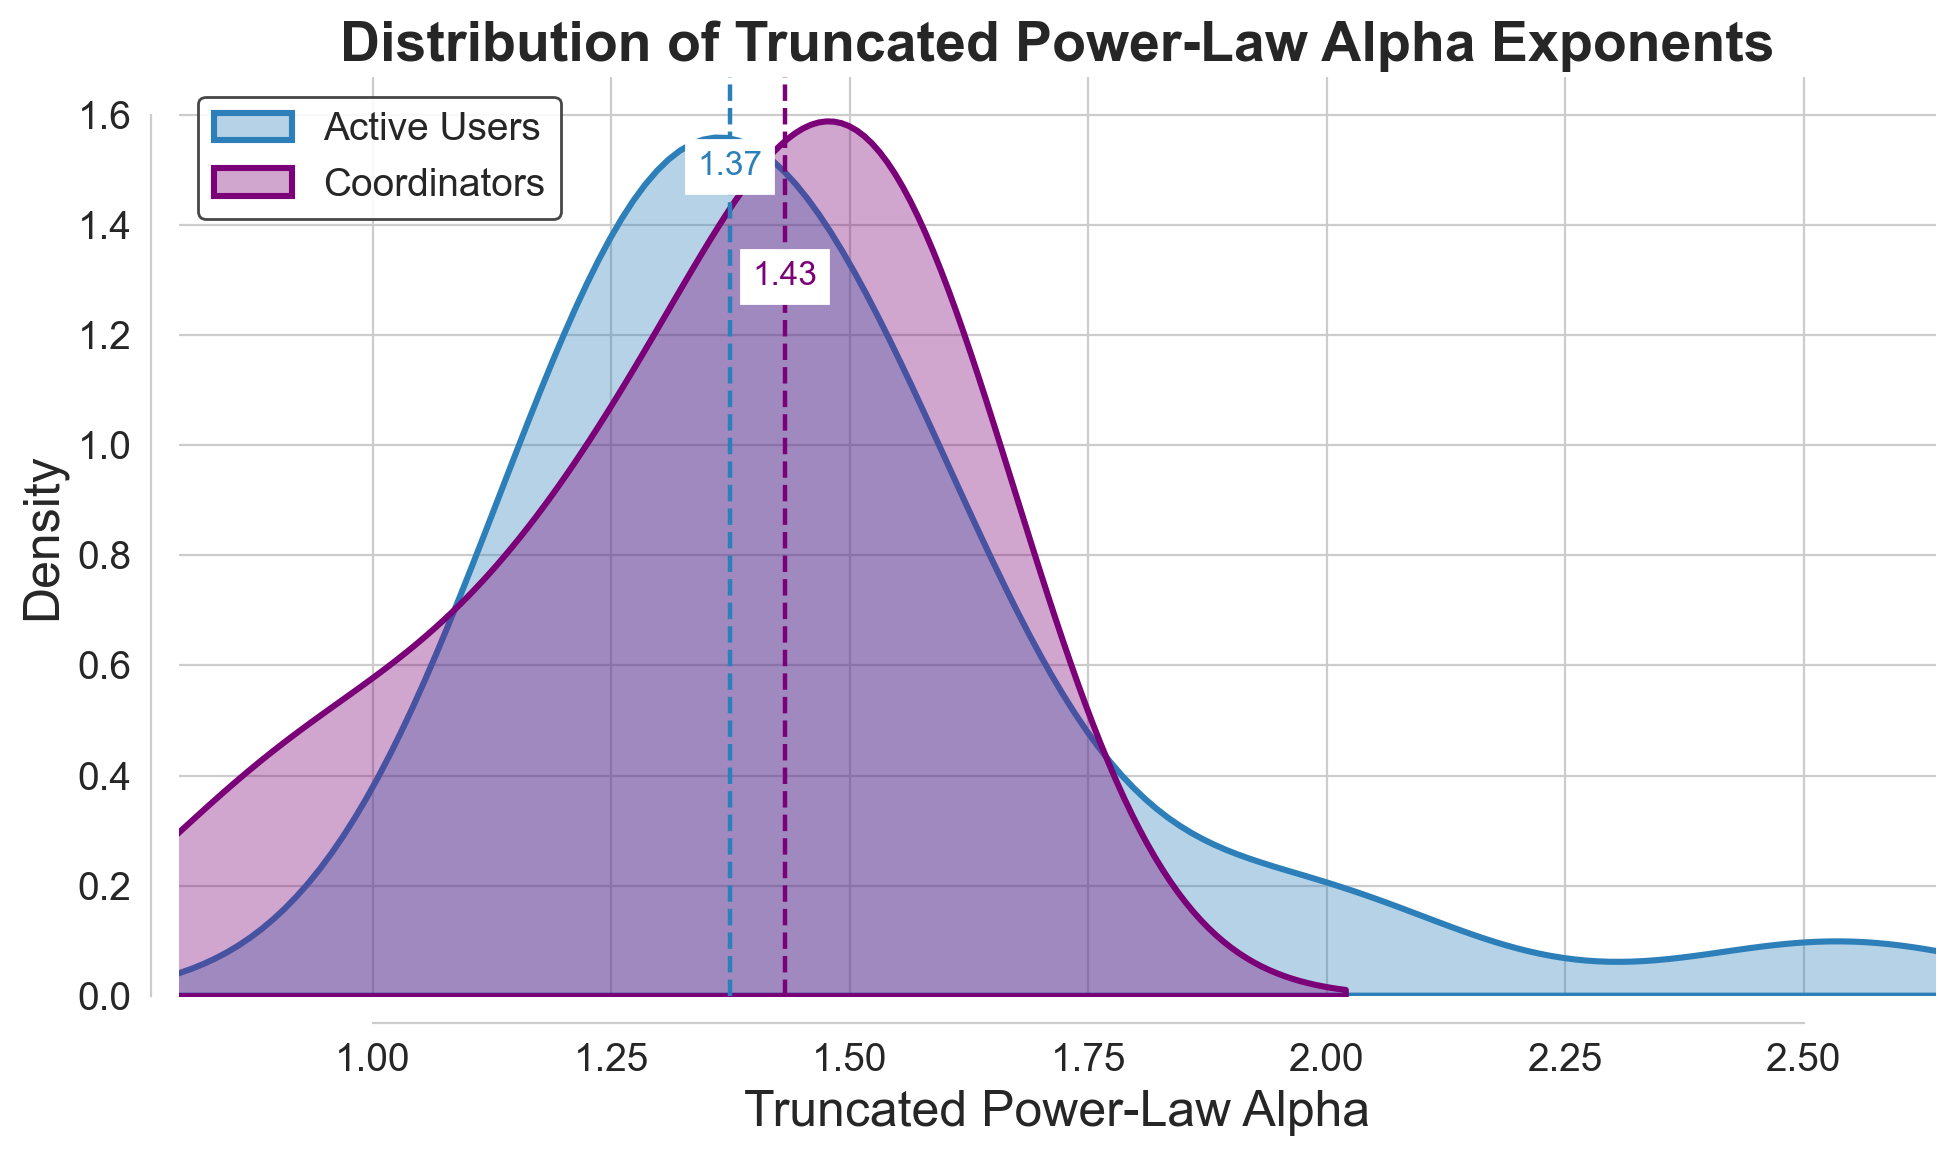

In [21]:
# Waiting times for the coordinators

import matplotlib as mpl
sns.set_style('whitegrid')
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titleweight': 'bold',
})

alphas_au, lambdas_au = extract_truncated_power_law_params(active_users, active_users_messages)
alphas_coord, lambdas_coord = extract_truncated_power_law_params(coordinators_id.values(), coordinators_messages)

# Define clear, high-contrast colors (avoid green and orange)
blue = '#2c7fb8'   # deep blue
purple = '#7a0177' # deep magenta

# Prepare arrays (handle empty cases)
au = np.asarray(alphas_au) if alphas_au is not None else np.array([])
coord = np.asarray(alphas_coord) if alphas_coord is not None else np.array([])

fig, ax = plt.subplots(figsize=(10,6), dpi=200)

# Compute sensible x-limits with padding
valid_vals = np.concatenate([au[~np.isnan(au)] if au.size else np.array([]), coord[~np.isnan(coord)] if coord.size else np.array([])])
if valid_vals.size > 0:
    xmin, xmax = np.min(valid_vals), np.max(valid_vals)
    pad = max(0.06 * (xmax - xmin), 0.1)
    ax.set_xlim(xmin - pad, xmax + pad)
else:
    ax.set_xlim(0.5, 3.0)

# Plot KDEs with thicker lines and translucent fills
if au.size:
    sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2, label='Active Users', bw_method='scott')
if coord.size:
    sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2, label='Coordinators', bw_method='scott')

# Add median lines and annotations for readability
ymax = ax.get_ylim()[1]
if au.size:
    med_au = np.nanmedian(au)
    ax.axvline(med_au, color=blue, linestyle='--', linewidth=1.6)
    ax.text(med_au, ymax * 0.92, f'{med_au:.2f}', color=blue, fontsize=12, ha='center', va='top', backgroundcolor='white')
if coord.size:
    med_coord = np.nanmedian(coord)
    ax.axvline(med_coord, color=purple, linestyle='--', linewidth=1.6)
    ax.text(med_coord, ymax * 0.80, f'{med_coord:.2f}', color=purple, fontsize=12, ha='center', va='top', backgroundcolor='white')

# Labels and title
ax.set_xlabel('Truncated Power-Law Alpha', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_title('Distribution of Truncated Power-Law Alpha Exponents', fontsize=20, weight='bold')

# Legend styling
leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2', framealpha=0.9, loc='upper left')
for text in leg.get_texts():
    text.set_fontsize(14)

# Improve ticks and spines
ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine(trim=True, offset=10)

plt.tight_layout()
plt.show()

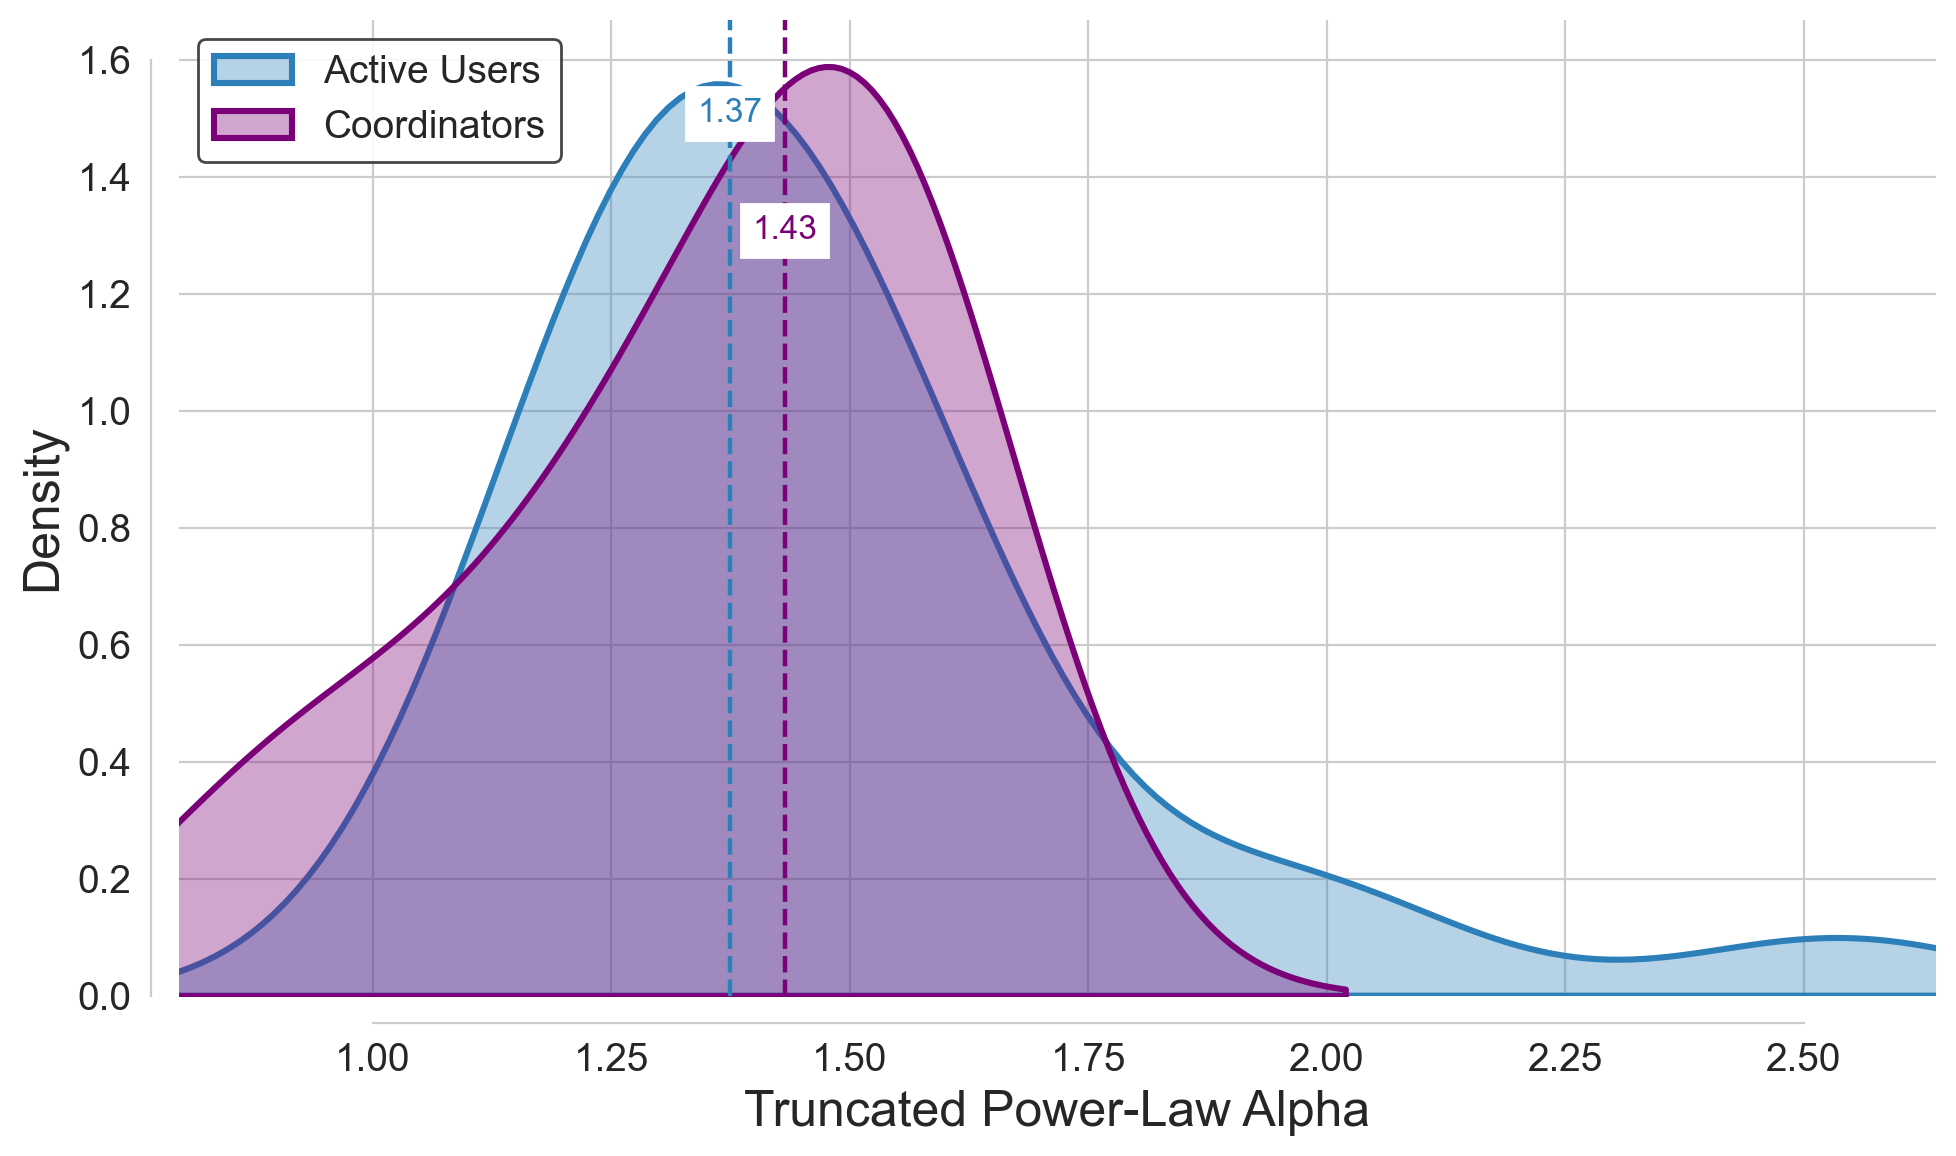

In [22]:
# Plot the distributions of alpha and lambda for each ideology group (improved styling for poster)
import matplotlib as mpl
sns.set_style('whitegrid')
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titleweight': 'bold',
})

# Colors (avoid green and orange)
blue = '#2c7fb8'
purple = '#7a0177'

fig, ax = plt.subplots(figsize=(10,6), dpi=200)
au = np.asarray(alphas_au) if alphas_au is not None else np.array([])
coord = np.asarray(alphas_coord) if alphas_coord is not None else np.array([])
valid_vals = np.concatenate([au[~np.isnan(au)] if au.size else np.array([]), coord[~np.isnan(coord)] if coord.size else np.array([])])
if valid_vals.size > 0:
    xmin, xmax = np.min(valid_vals), np.max(valid_vals)
    pad = max(0.06 * (xmax - xmin), 0.1)
    ax.set_xlim(xmin - pad, xmax + pad)
else:
    ax.set_xlim(0.5, 3.0)

# KDE plots
if au.size:
    sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2, label='Active Users', bw_method='scott')
if coord.size:
    sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2, label='Coordinators', bw_method='scott')

# Median lines and annotation
ymax = ax.get_ylim()[1]
if au.size:
    med_au = np.nanmedian(au)
    ax.axvline(med_au, color=blue, linestyle='--', linewidth=1.6)
    ax.text(med_au, ymax * 0.92, f'{med_au:.2f}', color=blue, fontsize=12, ha='center', va='top', backgroundcolor='white')
if coord.size:
    med_coord = np.nanmedian(coord)
    ax.axvline(med_coord, color=purple, linestyle='--', linewidth=1.6)
    ax.text(med_coord, ymax * 0.80, f'{med_coord:.2f}', color=purple, fontsize=12, ha='center', va='top', backgroundcolor='white')

ax.set_xlabel('Truncated Power-Law Alpha', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
#ax.set_title('Distribution of Truncated Power-Law Alpha Exponents', fontsize=20, weight='bold')

leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2', framealpha=0.9, loc='upper left')
for text in leg.get_texts():
    text.set_fontsize(14)

ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine(trim=True, offset=10)
plt.tight_layout()
plt.show()

In [23]:
# Recreate the poster-ready figure and save to PNG and SVG (robust exporter)
import os
import matplotlib as mpl
sns.set_style('whitegrid')
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titleweight': 'bold',
})

def save_truncated_alpha_fig(out_dir='figures', png_name='truncated_powerlaw_alpha.png', svg_name='truncated_powerlaw_alpha.svg', dpi=600):
    os.makedirs(out_dir, exist_ok=True)
    # Recompute the alpha arrays (safe to call multiple times)
    alphas_au, _ = extract_truncated_power_law_params(active_users, active_users_messages)
    alphas_coord, _ = extract_truncated_power_law_params(coordinators_id.values(), coordinators_messages)
    au = np.asarray(alphas_au) if alphas_au is not None else np.array([])
    coord = np.asarray(alphas_coord) if alphas_coord is not None else np.array([])

    # Colors (avoid green and orange)
    blue = '#2c7fb8'
    purple = '#7a0177'

    fig, ax = plt.subplots(figsize=(10,6), dpi=200)

    # Compute sensible x-limits with padding
    valid_vals = np.concatenate([au[~np.isnan(au)] if au.size else np.array([]), coord[~np.isnan(coord)] if coord.size else np.array([])])
    if valid_vals.size > 0:
        xmin, xmax = np.min(valid_vals), np.max(valid_vals)
        pad = max(0.06 * (xmax - xmin), 0.1)
        ax.set_xlim(xmin - pad, xmax + pad)
    else:
        ax.set_xlim(0.5, 3.0)

    # KDE plots
    if au.size:
        sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2, label='Active Users', bw_method='scott')
    if coord.size:
        sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2, label='Coordinators', bw_method='scott')

    # Median lines and annotation
    ymax = ax.get_ylim()[1]
    if au.size:
        med_au = np.nanmedian(au)
        ax.axvline(med_au, color=blue, linestyle='--', linewidth=1.6)
        ax.text(med_au, ymax * 0.92, f'{med_au:.2f}', color='white', fontsize=12, ha='center', va='top', bbox=dict(facecolor=blue, edgecolor='none', boxstyle='round,pad=0.3'))
    if coord.size:
        med_coord = np.nanmedian(coord)
        ax.axvline(med_coord, color=purple, linestyle='--', linewidth=1.6)
        ax.text(med_coord, ymax * 0.80, f'{med_coord:.2f}', color='white', fontsize=12, ha='center', va='top', bbox=dict(facecolor=purple, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.set_xlabel('Truncated Power-Law Alpha', fontsize=18)
    ax.set_ylabel('Density', fontsize=18)
    #ax.set_title('Distribution of Truncated Power-Law Alpha Exponents', fontsize=20, weight='bold')

    leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2', framealpha=0.9, loc='upper left')
    for text in leg.get_texts():
        text.set_fontsize(14)

    ax.tick_params(axis='both', which='major', labelsize=14)
    sns.despine(trim=True, offset=10)

    png_path = os.path.join(out_dir, png_name)
    svg_path = os.path.join(out_dir, svg_name)
    fig.savefig(png_path, dpi=dpi, bbox_inches='tight')
    fig.savefig(svg_path, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved PNG: {png_path}')
    print(f'Saved SVG: {svg_path}')

# Usage: run this cell (or call save_truncated_alpha_fig()) after any data cells are executed
save_truncated_alpha_fig()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 941865373: Not enough data to fit reliably (n=14).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 1568971431: Not enough data to fit reliably (n=5).
User 7154226214: Not enough data to fit reliably (n=13).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

Saved PNG: figures/truncated_powerlaw_alpha.png
Saved SVG: figures/truncated_powerlaw_alpha.svg
